# Poolman 2000 Calvin-Benson-Bassham cycle model.

Reference: Poolman, Mark G., David A. Fell, and Simon Thomas.  
"Modelling photosynthesis and its control."  
Journal of experimental botany 51.suppl_1 (2000): 319-328  

[DOI: 10.1093/jxb/erh090](https://www.doi.org/10.1093/jxb/erh090)

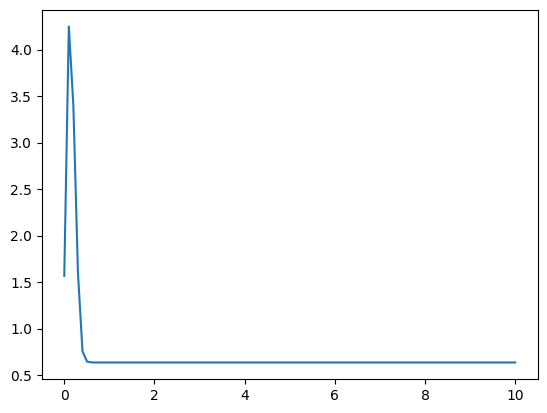

In [1]:
from functools import partial

import numpy as np
import pandas as pd
from mxlpy import Scipy

from mxlmodels import Simulator, get_poolman2000, plot, scan

import matplotlib.pyplot as plt

res = Simulator(get_poolman2000()).simulate(10).get_result().unwrap_or_err()

fig, ax = plt.subplots()

ax.plot(res.variables["Orthophosphate"])

## Re-create fig 3 - Effect of cytosolic phosphate

100%|██████████| 20/20 [00:11<00:00,  1.77it/s]


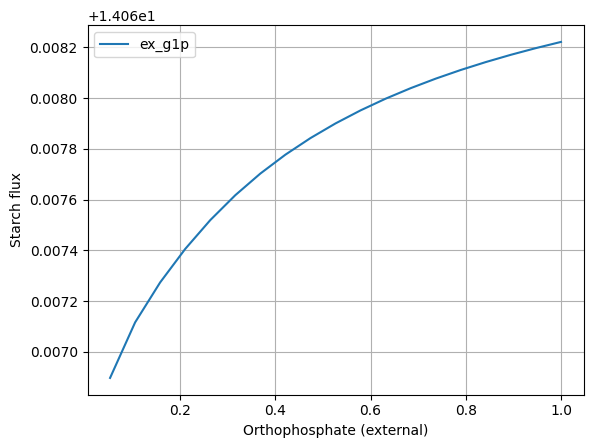

In [2]:
res = scan.steady_state(
    get_poolman2000(),
    to_scan=pd.DataFrame(
        {
            "Orthophosphate (external)": np.linspace(1e-10, 1, 20),
        }
    ),
    integrator=partial(Scipy, method="Radau"),
)

fig, ax = plot.lines(res.fluxes["ex_g1p"], ylabel="Starch flux")